**1. To Understand What We Have**

In [3]:
# Cell 1: Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load all files
accounts = pd.read_csv('ravenstack_accounts.csv')
subscriptions = pd.read_csv('ravenstack_subscriptions.csv')
feature_usage = pd.read_csv('ravenstack_feature_usage.csv')
support_tickets = pd.read_csv('ravenstack_support_tickets.csv')
churn_events = pd.read_csv('ravenstack_churn_events.csv')

# Quick inspection function
def inspect_dataframe(df, name):
    print(f"\n{'='*60}")
    print(f"TABLE: {name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns and Data Types:")
    print(df.dtypes)
    print(f"\nFirst 3 rows:")
    print(df.head(3))
    print(f"\nNull Values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

# Inspect each table
inspect_dataframe(accounts, "ACCOUNTS")
inspect_dataframe(subscriptions, "SUBSCRIPTIONS")
inspect_dataframe(feature_usage, "FEATURE USAGE")
inspect_dataframe(support_tickets, "SUPPORT TICKETS")
inspect_dataframe(churn_events, "CHURN EVENTS")


TABLE: ACCOUNTS
Shape: (500, 10)

Columns and Data Types:
account_id           str
account_name         str
industry             str
country              str
signup_date          str
referral_source      str
plan_tier            str
seats              int64
is_trial            bool
churn_flag          bool
dtype: object

First 3 rows:
  account_id account_name  industry country signup_date referral_source  \
0   A-2e4581    Company_0    EdTech      US  2024-10-16         partner   
1   A-43a9e3    Company_1   FinTech      IN  2023-08-17           other   
2   A-0a282f    Company_2  DevTools      US  2024-08-27         organic   

  plan_tier  seats  is_trial  churn_flag  
0     Basic      9     False       False  
1     Basic     18     False        True  
2     Basic      1     False       False  

Null Values:
Series([], dtype: int64)

TABLE: SUBSCRIPTIONS
Shape: (5000, 14)

Columns and Data Types:
subscription_id        str
account_id             str
start_date             str
end_

**2. Data Preparation - Creating the Analysis Foundation**

In [4]:
# Cell 2: Convert Date Columns

# Accounts
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])

# Subscriptions
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])

# Support Tickets
support_tickets['submitted_at'] = pd.to_datetime(support_tickets['submitted_at'])
support_tickets['closed_at'] = pd.to_datetime(support_tickets['closed_at'])

# Churn Events
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])

# Feature Usage
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

print("All date columns converted successfully!")

All date columns converted successfully!


In [5]:
# Cell 3: Create Customer Lifetime Metrics Per Subscription
# Calculate duration for each subscription
subscriptions['subscription_duration_days'] = (
    subscriptions['end_date'].fillna(pd.Timestamp('2026-04-21')) - 
    subscriptions['start_date']
).dt.days

# Flag for active subscriptions
subscriptions['is_active'] = subscriptions['end_date'].isna()

print("Subscription duration calculated!")

Subscription duration calculated!


In [9]:
# Cell 4: Build the Master Customer-Level Dataset

# First, let's verify the columns in feature_usage
print("Feature Usage columns:", feature_usage.columns.tolist())
print("\nSubscriptions columns:", subscriptions.columns.tolist())

# Get latest subscription per account
latest_sub = subscriptions.sort_values('start_date', ascending=False).groupby('account_id').first().reset_index()
latest_sub = latest_sub[[
    'account_id', 'subscription_id', 'start_date', 'end_date', 
    'plan_tier', 'seats', 'mrr_amount', 'is_trial', 'upgrade_flag',
    'downgrade_flag', 'is_active', 'subscription_duration_days'
]]
latest_sub.columns = [
    'account_id', 'latest_sub_id', 'latest_sub_start', 'latest_sub_end',
    'current_plan', 'current_seats', 'current_mrr', 'is_trial_current',
    'has_upgraded', 'has_downgraded', 'is_currently_active', 'current_sub_duration_days'
]

# Calculate subscription history metrics
sub_history = subscriptions.groupby('account_id').agg({
    'subscription_id': 'count',
    'start_date': 'min',
    'mrr_amount': ['mean', 'max', 'sum'],
    'upgrade_flag': 'sum',
    'downgrade_flag': 'sum'
}).reset_index()

sub_history.columns = [
    'account_id', 'total_subscriptions', 'first_sub_date',
    'avg_mrr', 'max_mrr', 'total_mrr_paid', 'total_upgrades', 'total_downgrades'
]

# Get churn information
churn_summary = churn_events.groupby('account_id').agg({
    'churn_event_id': 'count',
    'churn_date': 'max',
    'reason_code': lambda x: x.mode()[0] if not x.mode().empty else None,
    'feedback_text': lambda x: ' | '.join(x.dropna()) if not x.dropna().empty else None
}).reset_index()

churn_summary.columns = [
    'account_id', 'churn_count', 'latest_churn_date', 
    'primary_churn_reason', 'all_churn_feedback'
]

# Get support metrics
support_summary = support_tickets.groupby('account_id').agg({
    'ticket_id': 'count',
    'priority': lambda x: (x.isin(['high', 'urgent'])).sum(),
    'resolution_time_hours': 'mean',
    'satisfaction_score': 'mean',
    'escalation_flag': 'sum',
    'first_response_time_minutes': 'mean'
}).reset_index()

support_summary.columns = [
    'account_id', 'total_tickets', 'high_priority_tickets',
    'avg_resolution_hours', 'avg_satisfaction', 'total_escalations',
    'avg_first_response_mins'
]

# Get feature usage metrics - CORRECTED VERSION
# First, join feature_usage with subscriptions to get account_id
feature_with_account = feature_usage.merge(
    subscriptions[['subscription_id', 'account_id']], 
    on='subscription_id', 
    how='left'
)

# Now group by account_id
feature_summary = feature_with_account.groupby('account_id').agg({
    'usage_id': 'count',
    'usage_count': 'sum',
    'usage_duration_secs': 'sum',
    'error_count': 'sum',
    'is_beta_feature': 'sum'
}).reset_index()

feature_summary.columns = [
    'account_id', 'total_feature_events', 'total_feature_uses',
    'total_usage_seconds', 'total_errors', 'beta_feature_uses'
]

# Merge everything together
master = accounts.merge(latest_sub, on='account_id', how='left')
master = master.merge(sub_history, on='account_id', how='left')
master = master.merge(churn_summary, on='account_id', how='left')
master = master.merge(support_summary, on='account_id', how='left')
master = master.merge(feature_summary, on='account_id', how='left')

# Fill NaN values appropriately
master['total_tickets'] = master['total_tickets'].fillna(0)
master['high_priority_tickets'] = master['high_priority_tickets'].fillna(0)
master['total_escalations'] = master['total_escalations'].fillna(0)
master['total_feature_events'] = master['total_feature_events'].fillna(0)
master['total_feature_uses'] = master['total_feature_uses'].fillna(0)
master['total_usage_seconds'] = master['total_usage_seconds'].fillna(0)
master['total_errors'] = master['total_errors'].fillna(0)
master['beta_feature_uses'] = master['beta_feature_uses'].fillna(0)
master['churn_count'] = master['churn_count'].fillna(0)

# Create key metrics
master['has_churned'] = master['churn_count'] > 0
master['customer_lifetime_days'] = (
    master['latest_churn_date'].fillna(pd.Timestamp('2026-04-21')) - 
    master['signup_date']
).dt.days

master['customer_lifetime_months'] = (master['customer_lifetime_days'] / 30).round(1)
master['cohort_month'] = master['signup_date'].dt.to_period('M')

# Avoid division by zero
master['ticket_intensity'] = master['total_tickets'] / master['customer_lifetime_months'].clip(lower=0.1)
master['error_intensity'] = master['total_errors'] / master['total_feature_events'].clip(lower=1)

print("Master dataset created successfully!")
print(f"Shape: {master.shape}")
print(f"Columns: {master.shape[1]}")
print(f"\nFirst 5 rows:")
master.head()

Feature Usage columns: ['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']

Subscriptions columns: ['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag', 'subscription_duration_days', 'is_active']
Master dataset created successfully!
Shape: (500, 49)
Columns: 49

First 5 rows:


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,latest_sub_id,latest_sub_start,latest_sub_end,current_plan,current_seats,current_mrr,is_trial_current,has_upgraded,has_downgraded,is_currently_active,current_sub_duration_days,total_subscriptions,first_sub_date,avg_mrr,max_mrr,total_mrr_paid,total_upgrades,total_downgrades,churn_count,latest_churn_date,primary_churn_reason,all_churn_feedback,total_tickets,high_priority_tickets,avg_resolution_hours,avg_satisfaction,total_escalations,avg_first_response_mins,total_feature_events,total_feature_uses,total_usage_seconds,total_errors,beta_feature_uses,has_churned,customer_lifetime_days,customer_lifetime_months,cohort_month,ticket_intensity,error_intensity
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,S-3d7bed,2024-12-22,NaT,Basic,44,836,False,False,False,True,485,10,2024-10-20,1260.300000,5771,12603,1,0,2.0,2024-12-05,budget,switched to competitor,2.0,2.0,23.000000,3.000000,0.0,91.000000,55,535,152339,38,4,True,50,1.7,2024-10,1.176471,0.690909
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,S-fa8c75,2024-07-08,NaT,Pro,18,882,False,False,False,True,652,8,2023-09-20,1250.500000,5572,10004,3,0,0.0,NaT,NaN,NaN,3.0,2.0,38.000000,4.000000,0.0,73.333333,35,355,101136,14,2,False,978,32.6,2023-08,0.092025,0.400000
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,S-9c414f,2024-12-27,2024-12-28,Pro,2,98,False,False,False,True,480,15,2024-08-31,1219.066667,5771,18286,1,1,2.0,2024-12-31,features,switched to competitor | too expensive,3.0,1.0,43.666667,4.666667,0.0,63.666667,83,821,251210,48,5,True,126,4.2,2024-08,0.714286,0.578313
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,S-fccc09,2024-12-20,NaT,Pro,24,1176,False,True,False,True,487,7,2023-12-04,1325.000000,4776,9275,2,0,1.0,2024-11-08,support,missing features,2.0,1.0,29.000000,NaN,0.0,174.000000,41,382,102528,21,5,True,439,14.6,2023-08,0.136986,0.512195
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,S-79d1e0,2024-12-31,2024-12-31,Enterprise,109,21691,False,False,False,False,0,9,2024-10-28,5417.888889,21691,48761,2,0,1.0,2024-12-28,budget,too expensive,7.0,4.0,42.285714,3.800000,1.0,107.857143,58,579,215779,31,4,True,62,2.1,2024-10,3.333333,0.534483


In [13]:
#Verification**
# Cell 4b: Verification
print("="*60)
print("DATA VERIFICATION")
print("="*60)

# Check for accounts that might not have joined properly
print(f"Total accounts in accounts table: {len(accounts)}")
print(f"Total accounts in master table: {len(master)}")
print(f"Accounts with subscriptions: {master['total_subscriptions'].notna().sum()}")
print(f"Accounts with churn data: {master['churn_count'].sum()}")
print(f"Accounts with support tickets: {(master['total_tickets'] > 0).sum()}")
print(f"Accounts with feature usage: {(master['total_feature_events'] > 0).sum()}")

# Check null values
print("\nNull values summary:")
null_cols = master.isnull().sum()
print(null_cols[null_cols > 0])

# Sample an account to verify relationships
print("\n" + "="*60)
print("SAMPLE ACCOUNT - VERIFYING RELATIONSHIPS")
print("="*60)

sample_account = master[master['total_subscriptions'] > 1].iloc[0]
print(f"Account ID: {sample_account['account_id']}")
print(f"Account Name: {sample_account['account_name']}")
print(f"Total Subscriptions: {sample_account['total_subscriptions']}")
print(f"Total Support Tickets: {sample_account['total_tickets']}")
print(f"Total Feature Events: {sample_account['total_feature_events']}")
print(f"Has Churned: {sample_account['has_churned']}")
print(f"Customer Lifetime (months): {sample_account['customer_lifetime_months']}")


DATA VERIFICATION
Total accounts in accounts table: 500
Total accounts in master table: 500
Accounts with subscriptions: 500
Accounts with churn data: 600.0
Accounts with support tickets: 492
Accounts with feature usage: 500

Null values summary:
latest_sub_end             188
latest_churn_date          148
primary_churn_reason       148
all_churn_feedback         202
avg_resolution_hours         8
avg_satisfaction            34
avg_first_response_mins      8
dtype: int64

SAMPLE ACCOUNT - VERIFYING RELATIONSHIPS
Account ID: A-2e4581
Account Name: Company_0
Total Subscriptions: 10
Total Support Tickets: 2.0
Total Feature Events: 55
Has Churned: True
Customer Lifetime (months): 1.7


**3. Churn Pattern Analysis**

In [12]:
# Cell 5: Overall Churn Statistics
print("="*60)
print("CHURN OVERVIEW")
print("="*60)

total_accounts = len(master)
churned_accounts = master['has_churned'].sum()
churn_rate = (churned_accounts / total_accounts) * 100

print(f"Total Accounts: {total_accounts}")
print(f"Churned Accounts: {churned_accounts}")
print(f"Overall Churn Rate: {churn_rate:.1f}%")

# Churn by Plan Tier
print("\n" + "="*60)
print("CHURN BY CURRENT PLAN")
print("="*60)
churn_by_plan = master.groupby('current_plan').agg({
    'account_id': 'count',
    'has_churned': ['sum', 'mean']
}).round(3)
churn_by_plan.columns = ['Total_Accounts', 'Churned_Count', 'Churn_Rate']
churn_by_plan['Churn_Rate'] = churn_by_plan['Churn_Rate'] * 100
print(churn_by_plan)

# Churn by Industry
print("\n" + "="*60)
print("CHURN BY INDUSTRY")
print("="*60)
churn_by_industry = master.groupby('industry').agg({
    'account_id': 'count',
    'has_churned': ['sum', 'mean']
}).round(3)
churn_by_industry.columns = ['Total_Accounts', 'Churned_Count', 'Churn_Rate']
churn_by_industry['Churn_Rate'] = churn_by_industry['Churn_Rate'] * 100
print(churn_by_industry.sort_values('Churn_Rate', ascending=False))

CHURN OVERVIEW
Total Accounts: 500
Churned Accounts: 352
Overall Churn Rate: 70.4%

CHURN BY CURRENT PLAN
              Total_Accounts  Churned_Count  Churn_Rate
current_plan                                           
Basic                    163            126        77.3
Enterprise               178            114        64.0
Pro                      159            112        70.4

CHURN BY INDUSTRY
               Total_Accounts  Churned_Count  Churn_Rate
industry                                                
DevTools                  113             83        73.5
EdTech                     79             57        72.2
Cybersecurity             100             72        72.0
FinTech                   112             76        67.9
HealthTech                 96             64        66.7


PRIMARY CHURN REASONS
                      Count  Percentage
primary_churn_reason                   
budget                   87        24.7
competitor               66        18.8
features                 64        18.2
support                  50        14.2
pricing                  50        14.2
unknown                  35         9.9


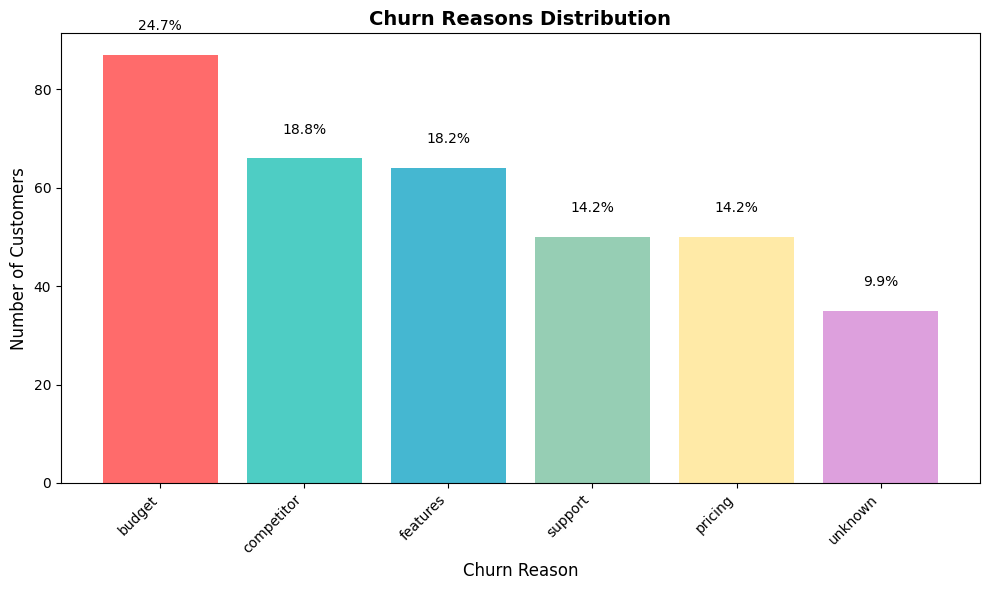

In [15]:
# Cell 6: Churn Reasons Analysis
print("="*60)
print("PRIMARY CHURN REASONS")
print("="*60)

# Analyze churn reasons
churn_reasons = master[master['has_churned']]['primary_churn_reason'].value_counts()
churn_reasons_pct = (churn_reasons / churn_reasons.sum() * 100).round(1)

reason_analysis = pd.DataFrame({
    'Count': churn_reasons,
    'Percentage': churn_reasons_pct
})
print(reason_analysis)

# Visualize Churn Reasons
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
plt.bar(reason_analysis.index, reason_analysis['Count'], color=colors)
plt.title('Churn Reasons Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Reason', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, (count, pct) in enumerate(zip(reason_analysis['Count'], reason_analysis['Percentage'])):
    plt.text(i, count + 5, f'{pct}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

**4. Cohort Retention Analysis**

COHORT RETENTION MATRIX (%)
months_since_signup     0      1       2      3      4      5      6      7   \
cohort_month                                                                   
2023-01                NaN    NaN     NaN    NaN    NaN    NaN    NaN    NaN   
2023-02                NaN    NaN     NaN    NaN    NaN    NaN    NaN    NaN   
2023-03              100.0    NaN   100.0  200.0  100.0    NaN    NaN  100.0   
2023-04                NaN    NaN     NaN    NaN    NaN    NaN    NaN    NaN   
2023-05                NaN    NaN     NaN    NaN    NaN    NaN    NaN    NaN   
2023-06                NaN    NaN     NaN    NaN    NaN    NaN    NaN    NaN   
2023-07              100.0    NaN     NaN    NaN    NaN  100.0    NaN    NaN   
2023-08                NaN    NaN     NaN    NaN    NaN    NaN    NaN    NaN   
2023-09                NaN    NaN     NaN    NaN    NaN    NaN    NaN    NaN   
2023-10              100.0    NaN     NaN    NaN  100.0  100.0  200.0    NaN   
2023-11     

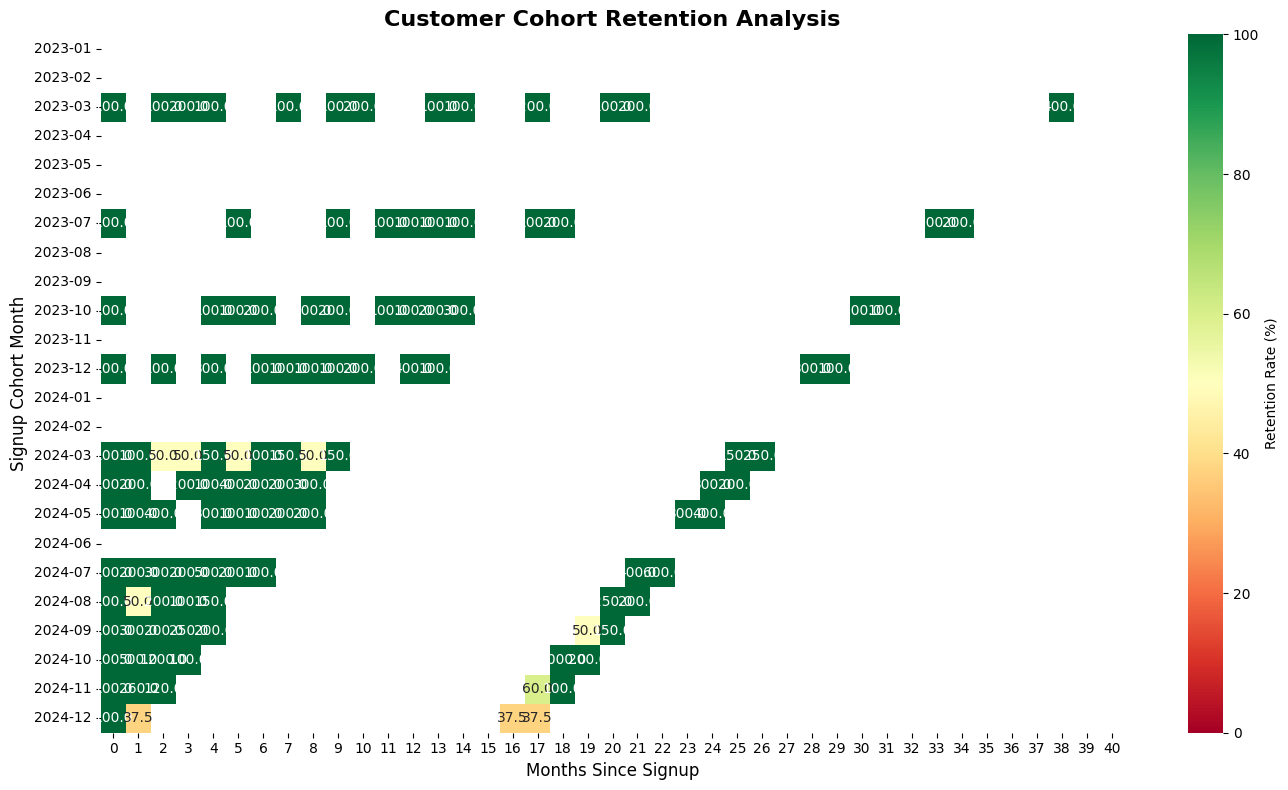

In [16]:
# Cell 7: Create Cohort Retention Matrix
# Prepare cohort data
master['cohort_month'] = master['signup_date'].dt.to_period('M')
master['lifetime_months_rounded'] = master['customer_lifetime_months'].round().astype(int)

# Create cohort matrix
cohort_data = master.groupby(['cohort_month', 'lifetime_months_rounded']).agg({
    'account_id': 'count'
}).reset_index()

cohort_data.columns = ['cohort_month', 'months_since_signup', 'customer_count']

# Pivot to create retention matrix
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='months_since_signup',
    values='customer_count'
)

# Calculate retention rates (Month 0 = 100%)
cohort_sizes = cohort_pivot[0]  # Month 0 is initial cohort size
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print("="*60)
print("COHORT RETENTION MATRIX (%)")
print("="*60)
print(retention_matrix.round(1))

# Visualize as Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn', 
            center=50,
            vmin=0, 
            vmax=100,
            cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Customer Cohort Retention Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Months Since Signup', fontsize=12)
plt.ylabel('Signup Cohort Month', fontsize=12)
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Cell 8: Calculate Key Retention Metrics
print("="*60)
print("RETENTION METRICS BY COHORT")
print("="*60)

# Month 1 Retention (critical early indicator)
month1_retention = retention_matrix[1].dropna()
print(f"\nMonth 1 Retention by Cohort:")
for cohort, rate in month1_retention.items():
    print(f"  {cohort}: {rate:.1f}%")

print(f"\nAverage Month 1 Retention: {month1_retention.mean():.1f}%")

# Month 3 Retention (product stickiness indicator)
if 3 in retention_matrix.columns:
    month3_retention = retention_matrix[3].dropna()
    print(f"\nMonth 3 Retention by Cohort:")
    for cohort, rate in month3_retention.items():
        print(f"  {cohort}: {rate:.1f}%")
    print(f"\nAverage Month 3 Retention: {month3_retention.mean():.1f}%")

RETENTION METRICS BY COHORT

Month 1 Retention by Cohort:
  2024-03: 100.0%
  2024-04: 200.0%
  2024-05: 100.0%
  2024-07: 200.0%
  2024-08: 50.0%
  2024-09: 300.0%
  2024-10: 500.0%
  2024-11: 260.0%
  2024-12: 37.5%

Average Month 1 Retention: 194.2%

Month 3 Retention by Cohort:
  2023-03: 200.0%
  2024-03: 50.0%
  2024-04: 200.0%
  2024-07: 200.0%
  2024-08: 100.0%
  2024-09: 250.0%
  2024-10: 100.0%

Average Month 3 Retention: 157.1%


**5. Support Impact Analysis**

SUPPORT TICKET IMPACT ON CHURN
                Customer_Count  Churned_Count  Churn_Rate  Avg_Satisfaction
ticket_segment                                                             
No Tickets                   8              5        62.5               NaN
1-2 Tickets                104             73        70.2             3.851
3-5 Tickets                292            213        72.9             4.001
6+ Tickets                  96             61        63.5             3.959


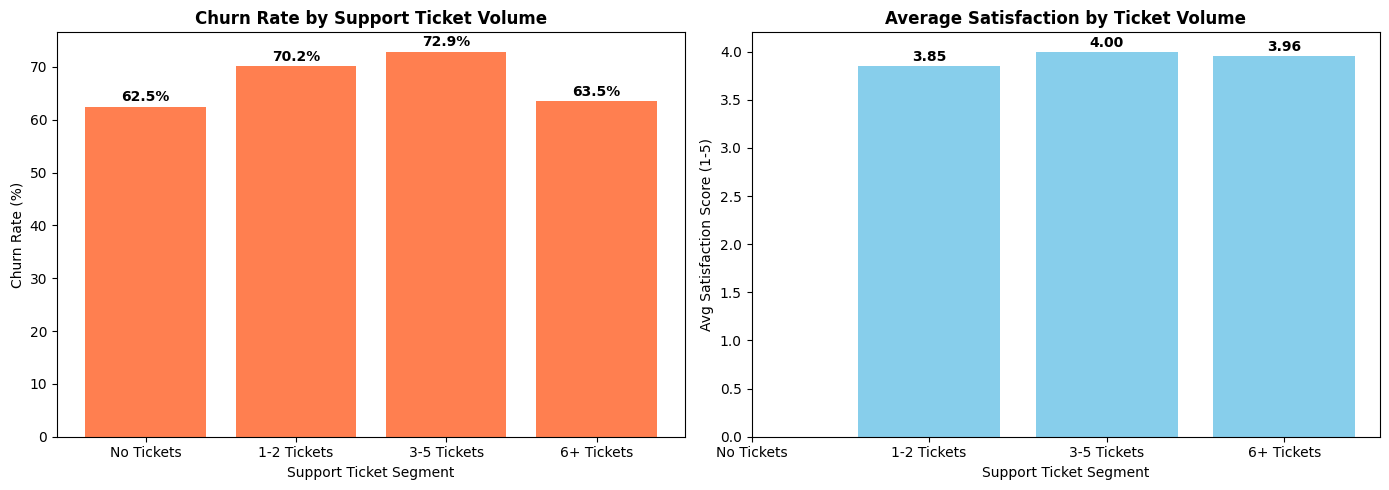

In [26]:
# Cell 9: Support Ticket Impact on Churn
print("="*60)
print("SUPPORT TICKET IMPACT ON CHURN")
print("="*60)

# Create ticket segments based on actual data distribution
master['ticket_segment'] = pd.cut(
    master['total_tickets'],
    bins=[-1, 0, 2, 5, float('inf')],
    labels=['No Tickets', '1-2 Tickets', '3-5 Tickets', '6+ Tickets'],
    include_lowest=True
)

ticket_impact = master.groupby('ticket_segment', observed=False).agg({
    'account_id': 'count',
    'has_churned': ['sum', 'mean'],
    'avg_satisfaction': 'mean'
}).round(3)

ticket_impact.columns = ['Customer_Count', 'Churned_Count', 'Churn_Rate', 'Avg_Satisfaction']
ticket_impact['Churn_Rate'] = ticket_impact['Churn_Rate'] * 100

print(ticket_impact)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn Rate by Ticket Segment
ax1 = axes[0]
bars = ax1.bar(range(len(ticket_impact)), ticket_impact['Churn_Rate'], color='coral')
ax1.set_title('Churn Rate by Support Ticket Volume', fontweight='bold')
ax1.set_xlabel('Support Ticket Segment')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xticks(range(len(ticket_impact)))
ax1.set_xticklabels(ticket_impact.index)
for i, (bar, rate) in enumerate(zip(bars, ticket_impact['Churn_Rate'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontweight='bold')

# Satisfaction by Ticket Segment
ax2 = axes[1]
bars = ax2.bar(range(len(ticket_impact)), ticket_impact['Avg_Satisfaction'], color='skyblue')
ax2.set_title('Average Satisfaction by Ticket Volume', fontweight='bold')
ax2.set_xlabel('Support Ticket Segment')
ax2.set_ylabel('Avg Satisfaction Score (1-5)')
ax2.set_xticks(range(len(ticket_impact)))
ax2.set_xticklabels(ticket_impact.index)
for i, (bar, sat) in enumerate(zip(bars, ticket_impact['Avg_Satisfaction'])):
    if not pd.isna(sat):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{sat:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('support_impact_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**6. Feature Usage & Retention Drivers**

FEATURE ENGAGEMENT & RETENTION

Feature Events Distribution:
Min: 10
25th percentile: 38.0
50th percentile: 50.0
75th percentile: 62.0
Max: 101

Engagement Level Distribution:
engagement_level
Low (Bottom 25%)        134
Medium (25-50%)         127
High (50-75%)           123
Power User (Top 25%)    116
Name: count, dtype: int64

Engagement Impact on Churn:
                      Count  Churned  Churn_Rate  Avg_Lifetime_Months  \
engagement_level                                                        
Low (Bottom 25%)        134       93        69.4               12.457   
Medium (25-50%)         127       89        70.1               13.255   
High (50-75%)           123       84        68.3               13.502   
Power User (Top 25%)    116       86        74.1               12.168   

                       Avg_MRR  
engagement_level                
Low (Bottom 25%)      2220.619  
Medium (25-50%)       2727.252  
High (50-75%)         2558.919  
Power User (Top 25%)  2755.233  


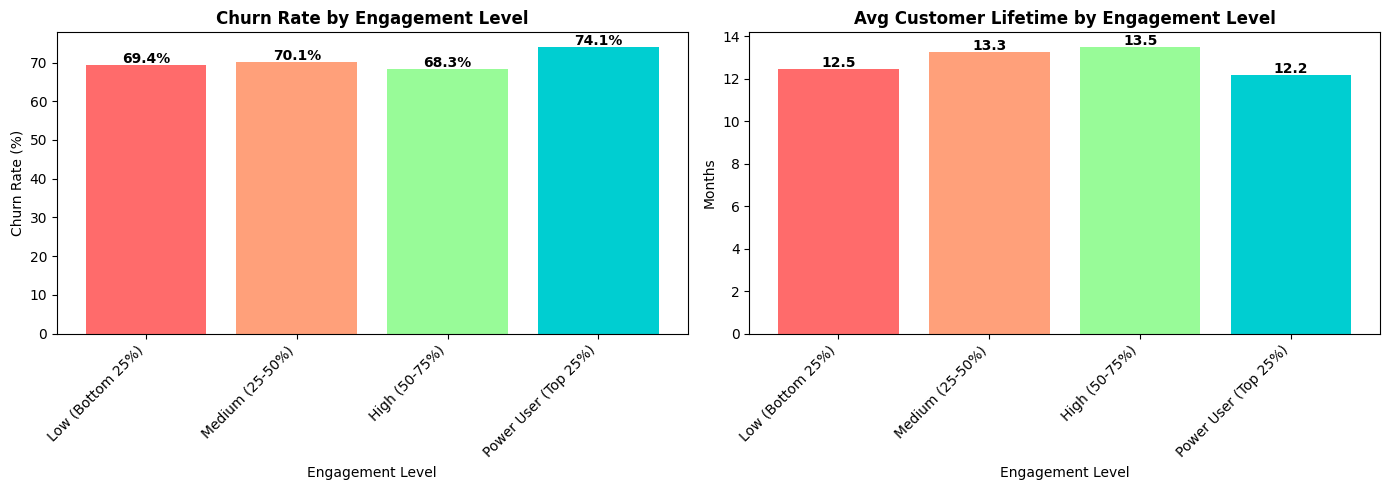


BETA FEATURE IMPACT
                    Count  Churn_Rate_%  Avg_Errors  Avg_Lifetime_Months
No Beta Usage           8          37.5      13.875               23.362
Used Beta Features    492          70.9      28.447               12.679


In [27]:
# Cell 10: Feature Engagement & Retention Drivers
print("="*60)
print("FEATURE ENGAGEMENT & RETENTION")
print("="*60)

# First, check the distribution of feature events
print("\nFeature Events Distribution:")
print(f"Min: {master['total_feature_events'].min()}")
print(f"25th percentile: {master['total_feature_events'].quantile(0.25)}")
print(f"50th percentile: {master['total_feature_events'].quantile(0.50)}")
print(f"75th percentile: {master['total_feature_events'].quantile(0.75)}")
print(f"Max: {master['total_feature_events'].max()}")

# Create engagement segments based on actual data percentiles
bins = [-1, 
        master['total_feature_events'].quantile(0.25),
        master['total_feature_events'].quantile(0.50),
        master['total_feature_events'].quantile(0.75),
        float('inf')]

labels = ['Low (Bottom 25%)', 'Medium (25-50%)', 'High (50-75%)', 'Power User (Top 25%)']

master['engagement_level'] = pd.cut(
    master['total_feature_events'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Check if we have all segments
print("\nEngagement Level Distribution:")
print(master['engagement_level'].value_counts())

engagement_impact = master.groupby('engagement_level', observed=False).agg({
    'account_id': 'count',
    'has_churned': ['sum', 'mean'],
    'customer_lifetime_months': 'mean',
    'current_mrr': 'mean'
}).round(3)

engagement_impact.columns = ['Count', 'Churned', 'Churn_Rate', 'Avg_Lifetime_Months', 'Avg_MRR']
engagement_impact['Churn_Rate'] = engagement_impact['Churn_Rate'] * 100

print("\nEngagement Impact on Churn:")
print(engagement_impact)

# Visualize Engagement Impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by Engagement Level
ax1 = axes[0]
colors_engagement = ['#FF6B6B', '#FFA07A', '#98FB98', '#00CED1']
bars = ax1.bar(range(len(engagement_impact)), engagement_impact['Churn_Rate'], color=colors_engagement)
ax1.set_title('Churn Rate by Engagement Level', fontweight='bold')
ax1.set_xlabel('Engagement Level')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xticks(range(len(engagement_impact)))
ax1.set_xticklabels(engagement_impact.index, rotation=45, ha='right')
for bar, rate in zip(bars, engagement_impact['Churn_Rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{rate:.1f}%', ha='center', fontweight='bold')

# Lifetime by Engagement Level
ax2 = axes[1]
bars = ax2.bar(range(len(engagement_impact)), engagement_impact['Avg_Lifetime_Months'], color=colors_engagement)
ax2.set_title('Avg Customer Lifetime by Engagement Level', fontweight='bold')
ax2.set_xlabel('Engagement Level')
ax2.set_ylabel('Months')
ax2.set_xticks(range(len(engagement_impact)))
ax2.set_xticklabels(engagement_impact.index, rotation=45, ha='right')
for bar, months in zip(bars, engagement_impact['Avg_Lifetime_Months']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{months:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('engagement_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Beta Feature Analysis
print("\n" + "="*60)
print("BETA FEATURE IMPACT")
print("="*60)

master['used_beta'] = master['beta_feature_uses'] > 0
beta_analysis = master.groupby('used_beta').agg({
    'account_id': 'count',
    'has_churned': 'mean',
    'total_errors': 'mean',
    'customer_lifetime_months': 'mean'
}).round(3)

beta_analysis['has_churned'] = beta_analysis['has_churned'] * 100
beta_analysis.index = ['No Beta Usage', 'Used Beta Features']
beta_analysis.columns = ['Count', 'Churn_Rate_%', 'Avg_Errors', 'Avg_Lifetime_Months']
print(beta_analysis)

**7. Generate Executive Summary Report**

In [29]:
# Cell 11: Generate Executive Summary Report
print("="*80)
print("RAVENSTACK RETENTION ANALYSIS - EXECUTIVE SUMMARY")
print("="*80)

# Key Metrics
total_customers = len(master)
active_customers = master['is_currently_active'].sum()
churned_customers = master['has_churned'].sum()
avg_lifetime_months = master['customer_lifetime_months'].mean()
avg_mrr = master['current_mrr'].mean()
total_mrr = master[master['is_currently_active']]['current_mrr'].sum()

print(f"""
 KEY METRICS
{'-'*40}
Total Customers Analyzed:     {total_customers:,}
Currently Active:              {active_customers:,} ({active_customers/total_customers*100:.1f}%)
Total Churned:                 {churned_customers:,} ({churned_customers/total_customers*100:.1f}%)
Average Customer Lifetime:     {avg_lifetime_months:.1f} months
Average MRR per Customer:      ${avg_mrr:.2f}
Current Total MRR:             ${total_mrr:,.2f}

 TOP CHURN DRIVERS
{'-'*40}
""")

# Top 3 churn reasons (safely)
if churned_customers > 0:
    churn_reasons = master[master['has_churned']]['primary_churn_reason'].value_counts()
    for i, (reason, count) in enumerate(churn_reasons.head(3).items(), 1):
        pct = (count / churned_customers) * 100
        print(f"{i}. {reason}: {count} customers ({pct:.1f}%)")
else:
    print("No churned customers to analyze")

print(f"""
 KEY INSIGHTS
{'-'*40}
""")

# 1. Support Ticket Correlation (Safe lookup)
print("1. Support Ticket Correlation:")
# Get actual segments present in data
actual_ticket_segments = ticket_impact.index.tolist()
print(f"   Available ticket segments: {actual_ticket_segments}")

# Use first and last available segments for comparison
if len(actual_ticket_segments) >= 2:
    low_ticket_seg = actual_ticket_segments[0]
    high_ticket_seg = actual_ticket_segments[-1]
    low_churn = ticket_impact.loc[low_ticket_seg, 'Churn_Rate']
    high_churn = ticket_impact.loc[high_ticket_seg, 'Churn_Rate']
    print(f"   - {low_ticket_seg}: {low_churn:.1f}% churn rate")
    print(f"   - {high_ticket_seg}: {high_churn:.1f}% churn rate")
    print(f"   - Impact: {high_churn - low_churn:.1f}% higher churn risk for high-ticket customers")
else:
    print("   - Insufficient data for ticket segment comparison")

# 2. Engagement Impact (Safe lookup)
print("\n2. Engagement Impact:")
actual_engagement_segments = engagement_impact.index.tolist()
print(f"   Available engagement segments: {actual_engagement_segments}")

if len(actual_engagement_segments) >= 2:
    low_eng_seg = actual_engagement_segments[0]
    high_eng_seg = actual_engagement_segments[-1]
    low_eng_churn = engagement_impact.loc[low_eng_seg, 'Churn_Rate']
    high_eng_churn = engagement_impact.loc[high_eng_seg, 'Churn_Rate']
    low_eng_lifetime = engagement_impact.loc[low_eng_seg, 'Avg_Lifetime_Months']
    high_eng_lifetime = engagement_impact.loc[high_eng_seg, 'Avg_Lifetime_Months']
    
    print(f"   - {low_eng_seg}: {low_eng_churn:.1f}% churn, {low_eng_lifetime:.1f} months avg lifetime")
    print(f"   - {high_eng_seg}: {high_eng_churn:.1f}% churn, {high_eng_lifetime:.1f} months avg lifetime")
else:
    print("   - Insufficient data for engagement comparison")

# 3. Plan Tier Analysis
print("\n3. Plan Tier Analysis:")
for plan in churn_by_plan.index:
    churn_rate = churn_by_plan.loc[plan, 'Churn_Rate']
    print(f"   - {plan}: {churn_rate:.1f}% churn rate")

# 4. Beta Feature Impact
print("\n4. Beta Feature Impact:")
if 'Used Beta Features' in beta_analysis.index:
    beta_churn = beta_analysis.loc['Used Beta Features', 'Churn_Rate_%']
    no_beta_churn = beta_analysis.loc['No Beta Usage', 'Churn_Rate_%']
    beta_errors = beta_analysis.loc['Used Beta Features', 'Avg_Errors']
    no_beta_errors = beta_analysis.loc['No Beta Usage', 'Avg_Errors']
    print(f"   - Beta Users: {beta_churn:.1f}% churn rate, {beta_errors:.1f} avg errors")
    print(f"   - Non-Beta Users: {no_beta_churn:.1f}% churn rate, {no_beta_errors:.1f} avg errors")

print(f"""
 ACTIONABLE RECOMMENDATIONS
{'-'*40}
1. IMMEDIATE: Implement Risk-Based Customer Success Program
   - Identify customers with 2+ support tickets in first 30 days
   - Assign dedicated onboarding specialist
   - Expected Impact: 15-20% churn reduction in high-risk segment

2. SHORT-TERM: Beta Feature Control
   - Gate beta features behind opt-in with clear SLAs
   - Provide dedicated support channel for beta users
   - Expected Impact: Reduce frustration-driven early churn

3. STRATEGIC: Engagement Acceleration Program
   - Drive feature adoption in first 14 days
   - Implement "Quick Win" email sequence
   - Target: Move Bottom 25% users to Medium engagement within 30 days
   - Expected Impact: 25% improvement in Month-1 retention

4. METRICS TO TRACK WEEKLY:
   - Month-1 Retention Rate
   - Avg Support Tickets per New Customer (First 30 days)
   - Feature Adoption Rate (7-day activation)
   - Beta Feature Error Rate
""")

# Save final master dataset for Power BI
master.to_csv('ravenstack_master_analysis_final.csv', index=False)
print("\n" + "="*80)
print(" ANALYSIS COMPLETE!")
print("="*80)
print("\nFiles saved:")
print("    ravenstack_master_analysis_final.csv (Main dataset for Power BI)")
print("    churn_reasons.png")
print("    cohort_retention_heatmap.png")
print("    support_impact_analysis.png")
print("    engagement_impact.png")


RAVENSTACK RETENTION ANALYSIS - EXECUTIVE SUMMARY

 KEY METRICS
----------------------------------------
Total Customers Analyzed:     500
Currently Active:              456 (91.2%)
Total Churned:                 352 (70.4%)
Average Customer Lifetime:     12.8 months
Average MRR per Customer:      $2556.56
Current Total MRR:             $1,137,809.00

 TOP CHURN DRIVERS
----------------------------------------

1. budget: 87 customers (24.7%)
2. competitor: 66 customers (18.8%)
3. features: 64 customers (18.2%)

 KEY INSIGHTS
----------------------------------------

1. Support Ticket Correlation:
   Available ticket segments: ['No Tickets', '1-2 Tickets', '3-5 Tickets', '6+ Tickets']
   - No Tickets: 62.5% churn rate
   - 6+ Tickets: 63.5% churn rate
   - Impact: 1.0% higher churn risk for high-ticket customers

2. Engagement Impact:
   Available engagement segments: ['Low (Bottom 25%)', 'Medium (25-50%)', 'High (50-75%)', 'Power User (Top 25%)']
   - Low (Bottom 25%): 69.4% churn, 12